IP keys: dict_keys(['sobel_hw_stream_0', 'DMA', 'processing_system7_0'])
DMA: <pynq.lib.dma.DMA object at 0xb48ada60>
Sobel regs: RegisterMap {
  CTRL = Register(AP_START=0, AP_DONE=0, AP_IDLE=1, AP_READY=0, RESERVED_1=0, AUTO_RESTART=0, RESERVED_2=0),
  GIER = Register(Enable=0, RESERVED=0),
  IP_IER = Register(CHAN0_INT_EN=0, CHAN1_INT_EN=0, RESERVED=0),
  IP_ISR = Register(CHAN0_INT_ST=0, CHAN1_INT_ST=0, RESERVED=0)
}
Output stats: 0 255 27.188308715820312
Wrote edges_hw.pgm


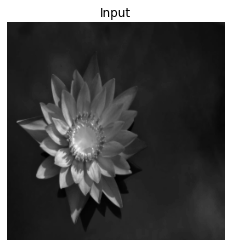

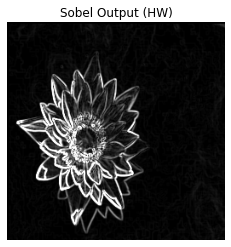

In [4]:
from pynq import Overlay, allocate
import numpy as np
import matplotlib.pyplot as plt
import time

# =========================
# Settings
# =========================
WIDTH, HEIGHT = 256, 256
N = WIDTH * HEIGHT

BITFILE = "design_1_wrapper.bit"   # change if needed

# =========================
# PGM helpers (P5, 8-bit)
# =========================
def read_pgm(path, w=WIDTH, h=HEIGHT):
    with open(path, "rb") as f:
        magic = f.readline().strip()
        if magic != b"P5":
            raise ValueError("Not a binary PGM (P5).")

        # Read width/height, skipping comments
        line = f.readline()
        while line.startswith(b"#"):
            line = f.readline()

        parts = line.split()
        if len(parts) < 2:
            parts += f.readline().split()

        ww, hh = int(parts[0]), int(parts[1])
        maxv = int(f.readline().strip())
        if maxv != 255:
            raise ValueError("Only 8-bit PGM (maxval=255) supported.")

        if ww != w or hh != h:
            raise ValueError(f"Expected {w}x{h}, got {ww}x{hh}")

        data = np.frombuffer(f.read(w*h), dtype=np.uint8)
        if data.size != w*h:
            raise ValueError("PGM file too short / corrupted.")
        return data.reshape((h, w))

def write_pgm(path, img):
    img = np.asarray(img, dtype=np.uint8)
    h, w = img.shape
    with open(path, "wb") as f:
        f.write(f"P5\n{w} {h}\n255\n".encode())
        f.write(img.tobytes())

# =========================
# Optional: load PNG/JPG and convert to 256x256 grayscale
# =========================
def load_image_any(path, w=WIDTH, h=HEIGHT):
    # Only needed if you want PNG/JPG support
    from PIL import Image
    img = Image.open(path).convert("L").resize((w, h))
    return np.array(img, dtype=np.uint8)

# =========================
# 1) Load overlay
# =========================
ol = Overlay(BITFILE)
ol.download()

print("IP keys:", ol.ip_dict.keys())

# DMA block is named "DMA" in your case
dma = ol.DMA

# Sobel block name may be sobel_hw_stream_0 (check keys above)
# If your name differs, change this line accordingly:
sobel = ol.sobel_hw_stream_0

print("DMA:", dma)
print("Sobel regs:", sobel.register_map)

# =========================
# 2) Choose input image source
# =========================
# Option A (PGM like your C testbench):
# Put "real_256.pgm" in the same folder as this notebook
img = read_pgm("real_256.pgm")

# Option B (PNG/JPG):
# img = load_image_any("myphoto.png")

# Fallback test pattern if you want:
# img = np.zeros((HEIGHT, WIDTH), dtype=np.uint8)
# np.fill_diagonal(img, 255)

assert img.shape == (HEIGHT, WIDTH)
assert img.dtype == np.uint8

# =========================
# 3) Allocate buffers
# =========================
in_buf  = allocate(shape=(N,), dtype=np.uint8)
out_buf = allocate(shape=(N,), dtype=np.uint8)

in_buf[:] = img.flatten()
out_buf[:] = 0

# =========================
# 4) Start Sobel IP
# =========================
# Start once (single-run)
sobel.write(0x00, 0x01)  # ap_start = 1

# If you plan to run multiple frames back-to-back, use auto-restart:
# sobel.write(0x00, 0x81)  # ap_start + auto_restart

# =========================
# 5) DMA transfer (KNOWN-GOOD ORDER)
# =========================
# Flush input buffer so PL sees fresh data
in_buf.flush()

# IMPORTANT: start receive BEFORE send (avoids stalls)
dma.recvchannel.transfer(out_buf)
dma.sendchannel.transfer(in_buf)

# Wait
dma.recvchannel.wait()
dma.sendchannel.wait()

# Invalidate output buffer so CPU sees updated data
out_buf.invalidate()

# =========================
# 6) Convert output back to image
# =========================
out_img = np.array(out_buf).reshape((HEIGHT, WIDTH))

print("Output stats:", out_img.min(), out_img.max(), float(out_img.mean()))

# Save output as PGM
write_pgm("edges_hw.pgm", out_img)
print("Wrote edges_hw.pgm")

# =========================
# 7) Display
# =========================
plt.figure()
plt.imshow(img, cmap="gray")
plt.title("Input")
plt.axis("off")

plt.figure()
plt.imshow(out_img, cmap="gray")
plt.title("Sobel Output (HW)")
plt.axis("off")
plt.show()
